In [351]:
import uproot
import awkward as ak
import matplotlib.pyplot as plt
import numpy as np
import vector
import matplotlib

In [370]:
# Names from json file:
names_json = ["SM","cQu8","ctu8","cQu1","ctd8","cQlMi","cpQ3","ctlTi","ctG","ctZ","ctW","ctli","ctb8","cbW","cQl3i","cQq13",
              "cptb","ctp","ctei","cpQM","ctlSi", "cQq83","cQq81","ctq1","ctu1","cQei","cQb8","cpt","ctq8","cQd1","cQq11",
              "cQd8","ctd1"]

# All 561 combinations of coefficients (i.e SM,SM; SM,cQu8; cQu8,cQu8; SM,ctu8; cQu8,ctu8; ...)
name_combinations = []
for i in range(len(names_json)):
    for a in range(i+1):
        name_combinations.append([names_json[i],names_json[a]])

In [371]:
# Open file
file = uproot.open("sample_root_files/output_570.root")

In [372]:
# Open Events tree
events_tree = file['Events']

In [373]:
# Making arrays of Jet pt and EFT Coefficients
jet_pt = events_tree['Jet_pt'].array()
eft_coeff = events_tree['EFTfitCoefficients'].array()

In [374]:
# Finding the index of the maximum coefficient in events with high and low jet pt.
jet_pt_above_500 = jet_pt[jet_pt > 500]
eft_coeff_above_500 = []
eft_coeff_below_500 = []

for i,n in enumerate(ak.num(jet_pt_above_500)):                                       # ak.num finds how many entries in a list/
    if n == 0:
        eft_coeff_below_500.append(np.argmax(np.abs(eft_coeff[i])))                   # np.argmax finds the index of the largest entry.
    else:
        eft_coeff_above_500.append(np.argmax(np.abs(eft_coeff[i])))

In [375]:
# Making it a percentage. The difference in the amount of events is drastic.
def weights(data):
    return [1 / len(data)] * len(data)

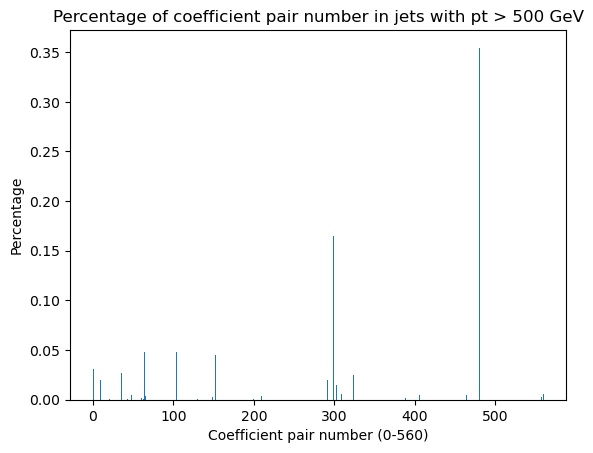

In [376]:
plt.hist(eft_coeff_above_500, bins = 520, weights = weights(eft_coeff_above_500))
plt.xlabel('Coefficient pair number (0-560)')
plt.ylabel('Percentage')
plt.title('Percentage of coefficient pair number in jets with pt > 500 GeV')
plt.show()

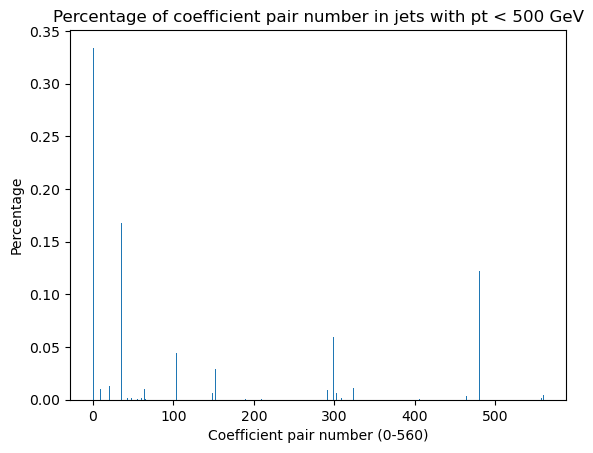

In [377]:
plt.hist(eft_coeff_below_500, bins=520, weights = weights(eft_coeff_below_500))
plt.xlabel('Coefficient pair number (0-560)')
plt.ylabel('Percentage')
plt.title('Percentage of coefficient pair number in jets with pt < 500 GeV')
plt.show()

In [378]:
def interesting_coeff(data,high_or_low):
    for i in range(561):
        coeff_percentage = data.count(i) / len(data)
        if coeff_percentage > 0.1:
            a = print(f'The pair {name_combinations[i]} has index {i} and has a percentage {round(coeff_percentage*100)}% in {high_or_low} pt')
    return a

In [379]:
interesting_coeff(eft_coeff_above_500,'high')

The pair ['ctG', 'ctG'] has index 44 and has a percentage 14% in high pt
The pair ['ctq1', 'ctq1'] has index 299 and has a percentage 17% in high pt
The pair ['cQq11', 'cQq13'] has index 480 and has a percentage 35% in high pt


In [380]:
interesting_coeff(eft_coeff_below_500,'low')

The pair ['SM', 'SM'] has index 0 and has a percentage 33% in low pt
The pair ['ctG', 'SM'] has index 36 and has a percentage 17% in low pt
The pair ['ctG', 'ctG'] has index 44 and has a percentage 14% in low pt
The pair ['cQq11', 'cQq13'] has index 480 and has a percentage 12% in low pt
